In [1]:
# ─────────────────────────────────────────────
# CELL 1: Install Dependencies (FIXED)
# ─────────────────────────────────────────────
# ⚠️ After this cell finishes → Runtime → Restart session → then run Cell 2 onwards

# Step 1: Force numpy to a version compatible with BOTH rembg and tensorflow
!pip install "numpy==2.0.2" -q --force-reinstall

# Step 2: Install onnxruntime (CPU — stable, no build errors)
!pip install "onnxruntime==1.19.2" -q

# Step 3: Install rembg pinned to last version that works with numpy 2.0.x
!pip install "rembg==2.0.57" -q

# Step 4: Install Pillow pinned below 12 (keeps gradio + other Colab libs happy)
!pip install "Pillow==10.4.0" -q --force-reinstall

# Step 5: DeepFace + keras backend
!pip install "deepface==0.0.93" -q
!pip install "tf-keras" -q

# Step 6: opencv (headless = no GUI deps, perfect for Colab)
!pip install "opencv-python-headless==4.10.0.84" -q

# ── Verify all packages ──────────────────────────────────────
print("\n" + "="*40)
print("  INSTALLATION VERIFICATION")
print("="*40)
packages = {
    "numpy":       "numpy",
    "rembg":       "rembg",
    "onnxruntime": "onnxruntime",
    "deepface":    "deepface",
    "cv2":         "cv2",
    "PIL":         "PIL",
}
all_ok = True
for name, mod in packages.items():
    try:
        m = __import__(mod)
        ver = getattr(m, "__version__", "ok")
        print(f"  ✅ {name:<15} {ver}")
    except ImportError as e:
        print(f"  ❌ {name:<15} FAILED — {e}")
        all_ok = False

print("="*40)
if all_ok:
    print("  ✅ All packages installed!")
    print("  👉 Now do: Runtime → Restart session")
    print("     Then run Cell 2 onwards.")
else:
    print("  ⚠️  Some packages failed. Scroll up for details.")
print("="*40)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9

In [1]:
# ─────────────────────────────────────────────
# CELL 2: Import Libraries
# ─────────────────────────────────────────────
# Run this AFTER restarting the runtime

import numpy as np
from PIL import Image, ImageFilter, ImageDraw
import cv2
import io
import os
import warnings
warnings.filterwarnings("ignore")

from rembg import remove
from deepface import DeepFace
from IPython.display import display

print("✅ All libraries imported successfully.")
print(f"   numpy   : {np.__version__}")
print(f"   Pillow  : {Image.__version__}")
print(f"   opencv  : {cv2.__version__}")

26-04-16 18:20:05 - Directory /root/.deepface has been created
26-04-16 18:20:05 - Directory /root/.deepface/weights has been created
✅ All libraries imported successfully.
   numpy   : 2.0.2
   Pillow  : 10.4.0
   opencv  : 4.10.0


In [2]:
# ─────────────────────────────────────────────
# CELL 3: Upload Image
# ─────────────────────────────────────────────

def upload_image_colab():
    """Upload image via Colab dialog. Returns PIL Image + filename."""
    from google.colab import files
    print("📂 Please upload a human face image (JPG/PNG)...")
    uploaded = files.upload()
    filename  = list(uploaded.keys())[0]
    img_bytes = uploaded[filename]
    image = Image.open(io.BytesIO(img_bytes)).convert("RGBA")
    print(f"✅ Uploaded: '{filename}' | Size: {image.size}")
    return image, filename


In [3]:
# ─────────────────────────────────────────────
# CELL 4: Background Removal
# ─────────────────────────────────────────────

def remove_background(input_image: Image.Image) -> Image.Image:
    """
    Remove image background using rembg (U²-Net pretrained).
    Returns RGBA PIL Image with transparent background.
    """
    print("🔪 Removing background with U²-Net (rembg)...")

    # PIL → bytes → rembg → PIL
    buf = io.BytesIO()
    input_image.save(buf, format="PNG")
    output_bytes = remove(buf.getvalue())
    output_image = Image.open(io.BytesIO(output_bytes)).convert("RGBA")

    print(f"✅ Background removed | Size: {output_image.size}")
    return output_image

In [4]:
# ─────────────────────────────────────────────
# CELL 5: Emotion Detection
# ─────────────────────────────────────────────

def detect_emotion(input_image: Image.Image):
    """
    Detect dominant facial emotion using DeepFace.
    Returns (emotion: str, confidence: float 0-1).
    Falls back to ('neutral', 0.5) if detection fails.
    """
    print("🧠 Analyzing facial emotion with DeepFace...")

    # PIL (RGBA) → RGB numpy array → BGR for DeepFace
    img_rgb = np.array(input_image.convert("RGB"))
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

    try:
        results = DeepFace.analyze(
            img_path          = img_bgr,
            actions           = ["emotion"],
            enforce_detection = False,   # no crash if face not found
            detector_backend  = "opencv" # fastest; use "retinaface" for accuracy
        )
        face       = results[0]
        emotion    = face["dominant_emotion"]
        confidence = face["emotion"][emotion] / 100.0

        print(f"✅ Emotion     : {emotion.upper()}")
        print(f"   Confidence  : {confidence:.2%}")
        print(f"   All scores  : { {k: f'{v:.1f}%' for k, v in face['emotion'].items()} }")
        return emotion, confidence

    except Exception as e:
        print(f"⚠️  Detection failed ({e}) → falling back to 'neutral'")
        return "neutral", 0.5


In [5]:
# ─────────────────────────────────────────────
# CELL 6: Chakra Color Mapping
# ─────────────────────────────────────────────

CHAKRA_MAP = {
    "happy":    {"color": (255, 223,   0), "chakra": "Solar Plexus", "hex": "#FFDF00"},
    "sad":      {"color": ( 30, 100, 210), "chakra": "Throat",       "hex": "#1E64D2"},
    "angry":    {"color": (220,  30,  30), "chakra": "Root",         "hex": "#DC1E1E"},
    "fear":     {"color": (128,   0, 200), "chakra": "Crown",        "hex": "#8000C8"},
    "disgust":  {"color": (100, 170,  30), "chakra": "Heart",        "hex": "#64AA1E"},
    "surprise": {"color": (255, 140,   0), "chakra": "Sacral",       "hex": "#FF8C00"},
    "neutral":  {"color": ( 50, 200, 120), "chakra": "Heart",        "hex": "#32C878"},
}

def map_chakra_color(emotion: str) -> dict:
    """Map detected emotion to chakra color data."""
    data = CHAKRA_MAP.get(emotion.lower().strip(), CHAKRA_MAP["neutral"])
    print(f"\n🌈 Chakra Mapping:")
    print(f"   Emotion → {emotion.upper()}")
    print(f"   Chakra  → {data['chakra']}")
    print(f"   Color   → {data['hex']}  RGB{data['color']}")
    return data

In [6]:
# ─────────────────────────────────────────────
# CELL 7: Aura Generation
# ─────────────────────────────────────────────

def generate_aura_background(size, chakra_color, confidence=0.75) -> Image.Image:
    """
    Generate radial gradient aura background with glow layers.
    Glow intensity and blur radius both scale with emotion confidence.
    """
    print("\n✨ Generating aura background...")
    width, height = size
    cx, cy = width // 2, height // 2
    r, g, b = chakra_color

    # Black base canvas
    canvas = Image.new("RGBA", size, (0, 0, 0, 255))
    draw   = ImageDraw.Draw(canvas)

    num_layers   = 20
    max_r_w      = int(width  * 0.85)
    max_r_h      = int(height * 0.85)
    max_alpha    = int(80 + confidence * 150)   # 80–230 based on confidence

    # Stack ellipse layers large→small for smooth radial gradient
    for i in range(num_layers, 0, -1):
        frac = i / num_layers
        ew   = int(max_r_w * frac)
        eh   = int(max_r_h * frac)

        # Outer rings faint, inner rings bright
        alpha = int(max_alpha * (1 - frac) ** 1.5)

        # Slightly lighter towards center
        blend = frac
        ri = int(r + (255 - r) * (1 - blend) * 0.4)
        gi = int(g + (255 - g) * (1 - blend) * 0.4)
        bi = int(b + (255 - b) * (1 - blend) * 0.4)

        draw.ellipse([cx-ew, cy-eh, cx+ew, cy+eh], fill=(ri, gi, bi, alpha))

    # Gaussian blur → soft glow bloom
    blur_radius = int(20 + confidence * 40)
    canvas = canvas.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    # Outer diffuse halo layer
    halo      = Image.new("RGBA", size, (0, 0, 0, 0))
    halo_draw = ImageDraw.Draw(halo)
    halo_draw.ellipse(
        [cx - max_r_w, cy - max_r_h, cx + max_r_w, cy + max_r_h],
        fill=(r, g, b, int(30 + confidence * 60))
    )
    halo   = halo.filter(ImageFilter.GaussianBlur(radius=60))
    canvas = Image.alpha_composite(canvas, halo)

    print(f"   Confidence: {confidence:.0%} | Blur: {blur_radius}px | Layers: {num_layers}")
    return canvas


def composite_final_image(fg_image: Image.Image, aura_bg: Image.Image) -> Image.Image:
    """Paste background-removed foreground onto aura background."""
    print("🖼️  Compositing foreground onto aura...")
    aura_resized = aura_bg.resize(fg_image.size, Image.LANCZOS)
    final = Image.alpha_composite(aura_resized, fg_image)
    print("✅ Done.")
    return final

In [7]:
# ─────────────────────────────────────────────
# CELL 8: Full Pipeline Runner
# ─────────────────────────────────────────────

def run_aura_pipeline(image_path=None):
    """
    End-to-end pipeline:
      upload → bg removal → emotion → chakra → aura → composite → display
    Pass image_path to load from disk; leave None to use Colab upload dialog.
    """
    print("=" * 55)
    print("  🌟  AURA VISUALIZATION AI PIPELINE")
    print("=" * 55)

    # ── Load image ───────────────────────────────────────────────
    if image_path and os.path.exists(image_path):
        print(f"📂 Loading: {image_path}")
        input_image = Image.open(image_path).convert("RGBA")
        print(f"✅ Size: {input_image.size}")
    else:
        input_image, _ = upload_image_colab()

    # Show original
    print("\n── Original ──")
    w, h = input_image.size
    prev = input_image.convert("RGB").resize((400, int(400*h/w)), Image.LANCZOS)
    display(prev)

    # ── Pipeline steps ───────────────────────────────────────────
    print("\n── Step 1: Background Removal ──")
    fg = remove_background(input_image)

    print("\n── Step 2: Emotion Detection ──")
    emotion, confidence = detect_emotion(fg)

    print("\n── Step 3: Chakra Mapping ──")
    chakra = map_chakra_color(emotion)

    print("\n── Step 4: Aura Generation ──")
    aura_bg = generate_aura_background(fg.size, chakra["color"], confidence)

    print("\n── Step 5: Compositing ──")
    final = composite_final_image(fg, aura_bg)

    # ── Results ──────────────────────────────────────────────────
    print("\n" + "=" * 55)
    print("  📊  RESULTS")
    print("=" * 55)
    print(f"  Emotion    : {emotion.upper()}")
    print(f"  Confidence : {confidence:.2%}")
    print(f"  Chakra     : {chakra['chakra']}")
    print(f"  Aura Color : {chakra['hex']}  RGB{chakra['color']}")
    print("=" * 55)

    # ── Display final ────────────────────────────────────────────
    print("\n✨ Final Aura Image:")
    fw, fh = final.size
    disp   = final.resize((500, int(500*fh/fw)), Image.LANCZOS)
    bg_out = Image.new("RGB", disp.size, (0, 0, 0))     # black bg for display
    bg_out.paste(disp, mask=disp.split()[3])
    display(bg_out)

    # ── Save + download ──────────────────────────────────────────
    out_file = f"aura_output_{emotion}.png"
    final.save(out_file, format="PNG")
    print(f"\n💾 Saved: '{out_file}'")

    try:
        from google.colab import files
        files.download(out_file)
        print("📥 Download triggered.")
    except ImportError:
        print("ℹ️  Running locally — file saved to disk.")

    return final, emotion, confidence, chakra

  🌟  AURA VISUALIZATION AI PIPELINE
📂 Please upload a human face image (JPG/PNG)...


Saving IMG_2296.PNG to IMG_2296.PNG
✅ Uploaded: 'IMG_2296.PNG' | Size: (1548, 2036)

── Original ──


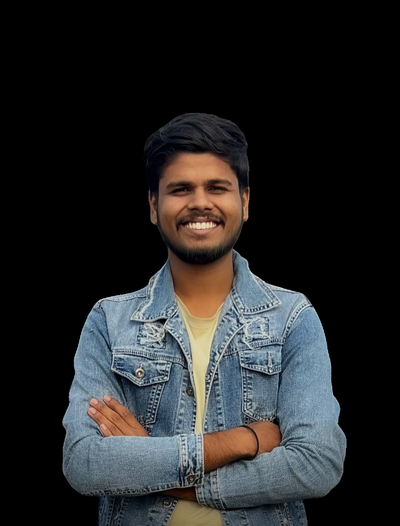


── Step 1: Background Removal ──
🔪 Removing background with U²-Net (rembg)...
✅ Background removed | Size: (1548, 2036)

── Step 2: Emotion Detection ──
🧠 Analyzing facial emotion with DeepFace...
✅ Emotion     : HAPPY
   Confidence  : 100.00%
   All scores  : {'angry': '0.0%', 'disgust': '0.0%', 'fear': '0.0%', 'happy': '100.0%', 'sad': '0.0%', 'surprise': '0.0%', 'neutral': '0.0%'}

── Step 3: Chakra Mapping ──

🌈 Chakra Mapping:
   Emotion → HAPPY
   Chakra  → Solar Plexus
   Color   → #FFDF00  RGB(255, 223, 0)

── Step 4: Aura Generation ──

✨ Generating aura background...
   Confidence: 100% | Blur: 59px | Layers: 20

── Step 5: Compositing ──
🖼️  Compositing foreground onto aura...
✅ Done.

  📊  RESULTS
  Emotion    : HAPPY
  Confidence : 100.00%
  Chakra     : Solar Plexus
  Aura Color : #FFDF00  RGB(255, 223, 0)

✨ Final Aura Image:


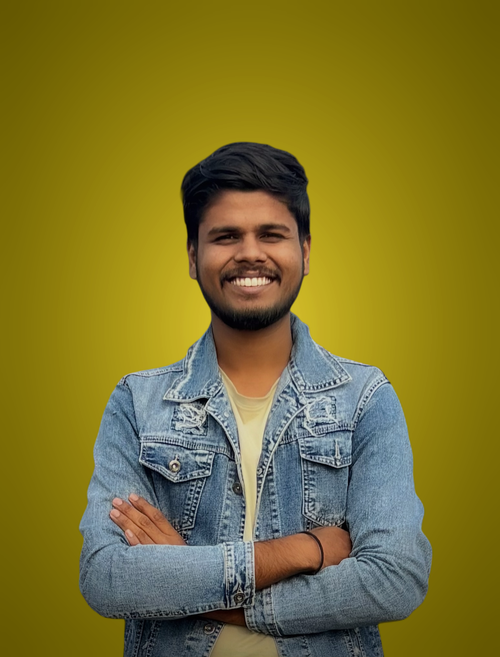


💾 Saved: 'aura_output_happy.png'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Download triggered.


In [11]:
# ─────────────────────────────────────────────
# CELL 9: Run the Pipeline
# ─────────────────────────────────────────────
# Option A — Colab upload dialog (default):
final_image, emotion, confidence, chakra = run_aura_pipeline()

# Option B — load from local path:
# final_image, emotion, confidence, chakra = run_aura_pipeline("face.jpg")

In [12]:
# ─────────────────────────────────────────────
# CELL 10 (Optional): Side-by-side Comparison
# ─────────────────────────────────────────────

def show_comparison(original_path, final_image):
    """Matplotlib side-by-side: original vs aura output."""
    import matplotlib.pyplot as plt

    original  = Image.open(original_path).convert("RGB")
    final_rgb = Image.new("RGB", final_image.size, (0, 0, 0))
    final_rgb.paste(final_image, mask=final_image.split()[3])

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.patch.set_facecolor("#0d0d1a")

    axes[0].imshow(original)
    axes[0].set_title("Original", color="white", fontsize=14, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(final_rgb)
    axes[1].set_title(
        f"Aura Output\n{emotion.upper()} → {chakra['chakra']} ({chakra['hex']})",
        color="white", fontsize=13, fontweight="bold"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig("aura_comparison.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("📊 Saved: aura_comparison.png")

# Uncomment to use:
# show_comparison("your_face.jpg", final_image)